# Regresja liniowa - minimum

Notebook pokazuje najprostszy pelny proces:
1. import bibliotek
2. wczytanie danych CSV
3. sprawdzenie danych
4. podzial na trening i test
5. trenowanie modelu
6. predykcja
7. wykres: ceny rzeczywiste vs przewidywane
8. testowanie modelu dla recznie podanych parametrow

## 1) Import bibliotek

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

## 2) Wczytanie danych

In [2]:
df = pd.read_csv("mieszkania_dane.csv")
df.head()

,metraz_m2,pokoje,pietro,odleglosc_km,rok_budowy,standard,cena_tys_pln
0,38,2,1,7.8,1980,2,462
1,42,2,3,6.9,1987,2,498
2,45,2,2,5.3,1995,3,551
3,47,2,4,4.8,1998,3,575
4,50,2,5,4.2,2003,3,604


## 3) Sprawdzenie wczytanych danych

In [3]:
print("Rozmiar danych:", df.shape)
print("\nTypy kolumn:")
print(df.dtypes)
print("\nPodstawowe statystyki:")
df.describe()

Rozmiar danych: (40, 7)

Typy kolumn:
metraz_m2         int64
pokoje            int64
pietro            int64
odleglosc_km    float64
rok_budowy        int64
standard          int64
cena_tys_pln      int64
dtype: object

Podstawowe statystyki:


,metraz_m2,pokoje,pietro,odleglosc_km,rok_budowy,standard,cena_tys_pln
count,40.00000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,76.92500,3.725000,5.025000,3.705000,2009.175000,4.050000,896.625000
std,20.21346,1.061868,2.684118,1.842232,11.142176,1.011473,248.746054
min,38.00000,2.000000,1.000000,1.200000,1980.000000,2.000000,462.000000
25%,61.50000,3.000000,3.000000,2.350000,2003.750000,3.000000,698.000000
50%,77.50000,4.000000,5.000000,3.150000,2012.000000,4.000000,900.500000
75%,93.50000,5.000000,7.000000,4.725000,2018.000000,5.000000,1069.500000
max,110.00000,5.000000,11.000000,8.100000,2023.000000,5.000000,1384.000000


## 4) Podzial na dane treningowe i testowe

In [4]:
feature_cols = ["metraz_m2", "pokoje", "pietro", "odleglosc_km", "rok_budowy", "standard"]
X = df[feature_cols]
y = df["cena_tys_pln"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)

X_train: (30, 6) X_test: (10, 6)


## 5) Trenowanie modelu

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model wytrenowany.")

Model wytrenowany.


## 6) Predykcja i prosta ocena modelu

In [6]:
y_pred = model.predict(X_test)
r2 = model.score(X_test, y_test)
print(f"R2 na zbiorze testowym: {r2:.4f}")

porownanie = pd.DataFrame({"cena_rzeczywista": y_test.values, "cena_przewidywana": y_pred})
porownanie.head()

R2 na zbiorze testowym: 0.9782


,cena_rzeczywista,cena_przewidywana
0,1014,1056.479217
1,874,921.079466
2,1032,1034.889310
3,1308,1269.171269
4,604,645.781232


## 7) Wykres: predykcja i ceny rzeczywiste

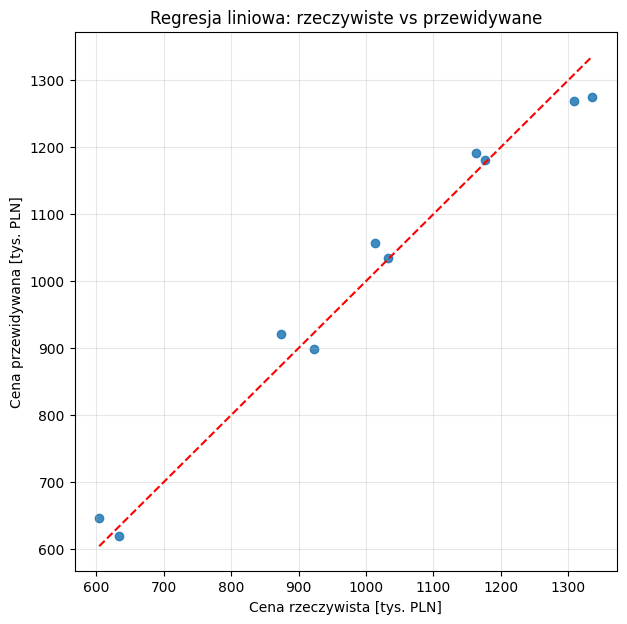

In [7]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.85)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--")

plt.xlabel("Cena rzeczywista [tys. PLN]")
plt.ylabel("Cena przewidywana [tys. PLN]")
plt.title("Regresja liniowa: rzeczywiste vs przewidywane")
plt.grid(True, alpha=0.3)
plt.show()

## 8) Testowanie modelu (reczne podawanie parametrow)

In [8]:
def predict_price(metraz_m2, pokoje, pietro, odleglosc_km, rok_budowy, standard):
    row = pd.DataFrame([{
        "metraz_m2": metraz_m2,
        "pokoje": pokoje,
        "pietro": pietro,
        "odleglosc_km": odleglosc_km,
        "rok_budowy": rok_budowy,
        "standard": standard,
    }])
    return model.predict(row)[0]

# Reczne podawanie parametrow:
metraz = float(input("Metraz [m2]: ").replace(",", "."))
pokoje = int(input("Liczba pokoi: "))
pietro = int(input("Pietro: "))
odleglosc = float(input("Odleglosc od centrum [km]: ").replace(",", "."))
rok = int(input("Rok budowy: "))
standard = int(input("Standard (1-5): "))

cena = predict_price(metraz, pokoje, pietro, odleglosc, rok, standard)
print(f"Przewidywana cena: {cena:.2f} tys. PLN")

Przewidywana cena: 537.02 tys. PLN
